In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:

import json
import os
import random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# ----------------------------------------------------------------------
# Config — edit these directly (works in scripts, Colab, and Jupyter)
# ----------------------------------------------------------------------
SEED = 42
LATENT_DIM = 20
VAE_EPOCHS = 20
CLASSIFIER_EPOCHS = 3           # oracle classifier, trained fast, separately
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
KL_WARMUP_EPOCHS = 5            # linearly ramp beta from 0 -> 1 over these epochs (stabilizes training)
RESULTS_DIR = "results"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]


TRANSFER_PAIRS = [
    (7, 9),  # Sneaker -> Ankle boot
    (0, 6),  # T-shirt/top -> Shirt
    (2, 4),  # Pullover -> Coat
]
ALPHAS = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]  # manipulation strength sweep


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# ----------------------------------------------------------------------
# Data
# ----------------------------------------------------------------------
def get_dataloaders():
    tfm = transforms.ToTensor()
    train_ds = datasets.FashionMNIST(root="./data", train=True, download=True, transform=tfm)
    test_ds = datasets.FashionMNIST(root="./data", train=False, download=True, transform=tfm)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2)
    return train_ds, test_ds, train_loader, test_loader


# ----------------------------------------------------------------------
# VAE model (convolutional encoder/decoder, 28x28x1 images)
# ----------------------------------------------------------------------
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1), nn.ReLU(),   # 28 -> 14
            nn.Conv2d(32, 64, 4, stride=2, padding=1), nn.ReLU(),  # 14 -> 7
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU(),  # 7 -> 4
        )
        self.flatten_dim = 128 * 4 * 4
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

    def forward(self, x):
        h = self.conv(x)
        h = h.view(h.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)


class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128 * 4 * 4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=0), nn.ReLU(),  # 4 -> 7
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(),   # 7 -> 14
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1), nn.Sigmoid(),  # 14 -> 28
        )

    def forward(self, z):
        h = self.fc(z)
        h = h.view(h.size(0), 128, 4, 4)
        return self.deconv(h)


class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar, z


def vae_loss(recon, x, mu, logvar, beta):
    recon_loss = F.binary_cross_entropy(recon, x, reduction="sum") / x.size(0)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + beta * kl_loss, recon_loss, kl_loss


# ----------------------------------------------------------------------
# Train the VAE
# ----------------------------------------------------------------------
def train_vae(train_loader, test_loader):
    model = VAE(LATENT_DIM).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    history = {"train_loss": [], "train_recon": [], "train_kl": [],
               "test_loss": [], "test_recon": [], "test_kl": []}

    for epoch in range(1, VAE_EPOCHS + 1):
        beta = min(1.0, epoch / KL_WARMUP_EPOCHS)  # linear KL warmup

        model.train()
        tot_loss = tot_recon = tot_kl = 0.0
        n = 0
        for x, _ in train_loader:
            x = x.to(DEVICE)
            optimizer.zero_grad()
            recon, mu, logvar, _ = model(x)
            loss, recon_loss, kl_loss = vae_loss(recon, x, mu, logvar, beta)
            loss.backward()
            optimizer.step()
            bs = x.size(0)
            tot_loss += loss.item() * bs
            tot_recon += recon_loss.item() * bs
            tot_kl += kl_loss.item() * bs
            n += bs

        model.eval()
        te_loss = te_recon = te_kl = 0.0
        tn = 0
        with torch.no_grad():
            for x, _ in test_loader:
                x = x.to(DEVICE)
                recon, mu, logvar, _ = model(x)
                loss, recon_loss, kl_loss = vae_loss(recon, x, mu, logvar, beta=1.0)
                bs = x.size(0)
                te_loss += loss.item() * bs
                te_recon += recon_loss.item() * bs
                te_kl += kl_loss.item() * bs
                tn += bs

        history["train_loss"].append(tot_loss / n)
        history["train_recon"].append(tot_recon / n)
        history["train_kl"].append(tot_kl / n)
        history["test_loss"].append(te_loss / tn)
        history["test_recon"].append(te_recon / tn)
        history["test_kl"].append(te_kl / tn)

        print(f"Epoch {epoch:2d}/{VAE_EPOCHS} | beta={beta:.2f} | "
              f"train ELBO={tot_loss / n:.2f} (recon={tot_recon / n:.2f}, kl={tot_kl / n:.2f}) | "
              f"test ELBO={te_loss / tn:.2f}")

    return model, history


# ----------------------------------------------------------------------
# Oracle classifier (small CNN), trained separately, used only to SCORE
# manipulated images quantitatively — not part of the VAE.
# ----------------------------------------------------------------------
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 28 -> 14
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 14 -> 7
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128), nn.ReLU(), nn.Linear(128, num_classes)
        )

    def forward(self, x):
        h = self.net(x)
        h = h.view(h.size(0), -1)
        return self.fc(h)


def train_oracle_classifier(train_loader, test_loader):
    clf = SmallCNN().to(DEVICE)
    optimizer = torch.optim.Adam(clf.parameters(), lr=1e-3)

    for epoch in range(1, CLASSIFIER_EPOCHS + 1):
        clf.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            logits = clf(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            optimizer.step()

    clf.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            preds = clf(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    acc = correct / total
    print(f"Oracle classifier test accuracy: {acc:.4f}")
    return clf, acc


# ----------------------------------------------------------------------
# Visualization 1: reconstructions
# ----------------------------------------------------------------------
def plot_reconstructions(model, test_loader, out_path, n=8):
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    model.eval()
    x, _ = next(iter(test_loader))
    x = x[:n].to(DEVICE)
    with torch.no_grad():
        recon, _, _, _ = model(x)

    fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))
    for i in range(n):
        axes[0, i].imshow(x[i, 0].cpu(), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(recon[i, 0].cpu(), cmap="gray")
        axes[1, i].axis("off")
    axes[0, 0].set_ylabel("Original", fontsize=10)
    axes[1, 0].set_ylabel("Reconstructed", fontsize=10)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()
    print(f"Saved {out_path}")


# ----------------------------------------------------------------------
# Visualization 2: random samples from the prior
# ----------------------------------------------------------------------
def plot_random_samples(model, out_path, n=64):
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    model.eval()
    with torch.no_grad():
        z = torch.randn(n, LATENT_DIM).to(DEVICE)
        samples = model.decoder(z).cpu()

    grid_size = int(n ** 0.5)
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(samples[i, 0], cmap="gray")
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()
    print(f"Saved {out_path}")


# ----------------------------------------------------------------------
# Visualization 3: interpolation between two encodings
# ----------------------------------------------------------------------
def plot_interpolation(model, test_ds, out_path, n_steps=10):
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    model.eval()
    rng = np.random.RandomState(SEED)
    idx_a, idx_b = rng.choice(len(test_ds), size=2, replace=False)
    x_a = test_ds[idx_a][0].unsqueeze(0).to(DEVICE)
    x_b = test_ds[idx_b][0].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        mu_a, _ = model.encoder(x_a)
        mu_b, _ = model.encoder(x_b)
        alphas = np.linspace(0, 1, n_steps)
        frames = []
        for a in alphas:
            z = (1 - a) * mu_a + a * mu_b
            frames.append(model.decoder(z).cpu())

    fig, axes = plt.subplots(1, n_steps, figsize=(n_steps * 1.3, 1.6))
    for i, ax in enumerate(axes):
        ax.imshow(frames[i][0, 0], cmap="gray")
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()
    print(f"Saved {out_path}")


# ----------------------------------------------------------------------
# Visualization 4: 2-D PCA projection of the latent space, colored by class
# ----------------------------------------------------------------------
def encode_dataset(model, loader):
    model.eval()
    all_mu, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            mu, _ = model.encoder(x)
            all_mu.append(mu.cpu().numpy())
            all_labels.append(y.numpy())
    return np.concatenate(all_mu), np.concatenate(all_labels)


def plot_latent_pca(latents, labels, out_path):
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA

    pca = PCA(n_components=2, random_state=SEED)
    proj = pca.fit_transform(latents)

    plt.figure(figsize=(8, 7))
    scatter = plt.scatter(proj[:, 0], proj[:, 1], c=labels, cmap="tab10", s=4, alpha=0.5)
    handles, _ = scatter.legend_elements(num=10)
    plt.legend(handles, CLASS_NAMES, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("VAE Latent Space (PCA projection), colored by class")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()
    print(f"Saved {out_path}")
    return pca


# ----------------------------------------------------------------------
# ORIGINAL CONTRIBUTION: quantitative latent-space attribute manipulation
# ----------------------------------------------------------------------
def compute_class_mean_latents(latents, labels):
    means = {}
    for c in range(10):
        mask = labels == c
        means[c] = latents[mask].mean(axis=0)
    return means


def run_attribute_manipulation(model, oracle, latents, labels, test_ds, out_dir):
 
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    class_means = compute_class_mean_latents(latents, labels)
    results = {}

    fig_curve, ax_curve = plt.subplots(figsize=(7, 5))

    for source_c, target_c in TRANSFER_PAIRS:
        direction = class_means[target_c] - class_means[source_c]
        direction = torch.tensor(direction, dtype=torch.float32, device=DEVICE)

        # Take a batch of real source-class latents (via encoder, using their mu)
        source_mask = labels == source_c
        source_indices = np.where(source_mask)[0][:200]  # up to 200 examples
        source_latents = torch.tensor(latents[source_indices], dtype=torch.float32, device=DEVICE)

        flip_rates = []
        example_images_per_alpha = []
        for alpha in ALPHAS:
            z_manip = source_latents + alpha * direction
            with torch.no_grad():
                decoded = model.decoder(z_manip)
                logits = oracle(decoded)
                preds = logits.argmax(dim=1)
            flip_rate = (preds == target_c).float().mean().item()
            flip_rates.append(flip_rate)
            example_images_per_alpha.append(decoded[0].cpu())  # keep first example for the qualitative grid

        pair_key = f"{CLASS_NAMES[source_c]}->{CLASS_NAMES[target_c]}"
        results[pair_key] = {"alphas": ALPHAS, "flip_rate": flip_rates}
        ax_curve.plot(ALPHAS, flip_rates, marker="o", label=pair_key)

        # Qualitative grid for this pair: same example at each alpha
        fig, axes = plt.subplots(1, len(ALPHAS), figsize=(len(ALPHAS) * 1.4, 1.8))
        for i, img in enumerate(example_images_per_alpha):
            axes[i].imshow(img[0], cmap="gray")
            axes[i].set_title(f"a={ALPHAS[i]}", fontsize=8)
            axes[i].axis("off")
        fig.suptitle(f"{pair_key} — manipulation strength sweep", fontsize=10)
        plt.tight_layout()
        safe_name = pair_key.replace("/", "-").replace(" ", "_").replace(">", "")
        fig.savefig(os.path.join(out_dir, f"attribute_manipulation_{safe_name}.png"), dpi=150)
        plt.close(fig)

    ax_curve.set_xlabel("Manipulation strength (alpha)")
    ax_curve.set_ylabel("Oracle flip rate (fraction classified as target class)")
    ax_curve.set_title("Quantitative Latent-Space Attribute Manipulation")
    ax_curve.legend()
    ax_curve.grid(True, linestyle="--", alpha=0.4)
    fig_curve.tight_layout()
    fig_curve.savefig(os.path.join(out_dir, "manipulation_success_curve.png"), dpi=150)
    plt.close(fig_curve)
    print(f"Saved {os.path.join(out_dir, 'manipulation_success_curve.png')}")

    return results


# ----------------------------------------------------------------------
# Main — runs top-to-bottom, no argparse, safe inside Colab/Jupyter
# ----------------------------------------------------------------------
os.makedirs(RESULTS_DIR, exist_ok=True)
set_seed(SEED)
print(f"Using device: {DEVICE}")

print("Loading Fashion-MNIST...")
train_ds, test_ds, train_loader, test_loader = get_dataloaders()

print("\n=== Training VAE ===")
vae_model, history = train_vae(train_loader, test_loader)

print("\n=== Training oracle classifier (for scoring manipulated images) ===")
oracle_clf, oracle_acc = train_oracle_classifier(train_loader, test_loader)

print("\n=== Generating visualizations ===")
plot_reconstructions(vae_model, test_loader, os.path.join(RESULTS_DIR, "vae_reconstructions.png"))
plot_random_samples(vae_model, os.path.join(RESULTS_DIR, "vae_random_samples.png"))
plot_interpolation(vae_model, test_ds, os.path.join(RESULTS_DIR, "vae_interpolation.png"))

print("\n=== Encoding test set for latent-space analysis ===")
test_latents, test_labels = encode_dataset(vae_model, test_loader)
plot_latent_pca(test_latents, test_labels, os.path.join(RESULTS_DIR, "latent_space_pca.png"))

print("\n=== Original contribution: quantitative attribute manipulation ===")
manipulation_results = run_attribute_manipulation(
    vae_model, oracle_clf, test_latents, test_labels, test_ds, RESULTS_DIR
)

# Save all numeric results
metrics = {
    "vae_training_history": history,
    "oracle_classifier_test_accuracy": oracle_acc,
    "attribute_manipulation": manipulation_results,
    "config": {
        "latent_dim": LATENT_DIM,
        "vae_epochs": VAE_EPOCHS,
        "kl_warmup_epochs": KL_WARMUP_EPOCHS,
        "seed": SEED,
        "transfer_pairs": [[CLASS_NAMES[s], CLASS_NAMES[t]] for s, t in TRANSFER_PAIRS],
    },
}
with open(os.path.join(RESULTS_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)

print(f"\nDone. All results are in the '{RESULTS_DIR}/' directory.")
print(f"Final test ELBO: {history['test_loss'][-1]:.2f}")
print(f"Oracle classifier accuracy: {oracle_acc:.4f}")
for pair_key, res in manipulation_results.items():
    print(f"  {pair_key}: flip rate {res['flip_rate'][0]:.2f} (alpha=0) -> "
          f"{res['flip_rate'][-1]:.2f} (alpha={ALPHAS[-1]})")

Using device: cuda
Loading Fashion-MNIST...


100%|██████████| 26.4M/26.4M [00:02<00:00, 9.18MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 135kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.47MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.6MB/s]



=== Training VAE ===
Epoch  1/20 | beta=0.20 | train ELBO=262.29 (recon=255.03, kl=36.33) | test ELBO=267.39
Epoch  2/20 | beta=0.40 | train ELBO=238.14 (recon=226.31, kl=29.58) | test ELBO=253.86
Epoch  3/20 | beta=0.60 | train ELBO=238.99 (recon=224.41, kl=24.31) | test ELBO=249.39
Epoch  4/20 | beta=0.80 | train ELBO=241.26 (recon=224.58, kl=20.86) | test ELBO=246.43
Epoch  5/20 | beta=1.00 | train ELBO=243.74 (recon=225.45, kl=18.29) | test ELBO=244.72
Epoch  6/20 | beta=1.00 | train ELBO=242.53 (recon=224.77, kl=17.76) | test ELBO=243.36
Epoch  7/20 | beta=1.00 | train ELBO=241.50 (recon=224.07, kl=17.43) | test ELBO=243.07
Epoch  8/20 | beta=1.00 | train ELBO=240.93 (recon=223.69, kl=17.24) | test ELBO=242.21
Epoch  9/20 | beta=1.00 | train ELBO=240.26 (recon=223.18, kl=17.09) | test ELBO=242.16
Epoch 10/20 | beta=1.00 | train ELBO=239.88 (recon=222.92, kl=16.96) | test ELBO=241.54
Epoch 11/20 | beta=1.00 | train ELBO=239.49 (recon=222.58, kl=16.91) | test ELBO=241.07
Epoch 12/2

attribute_manipulation_Pullover-Coat.png


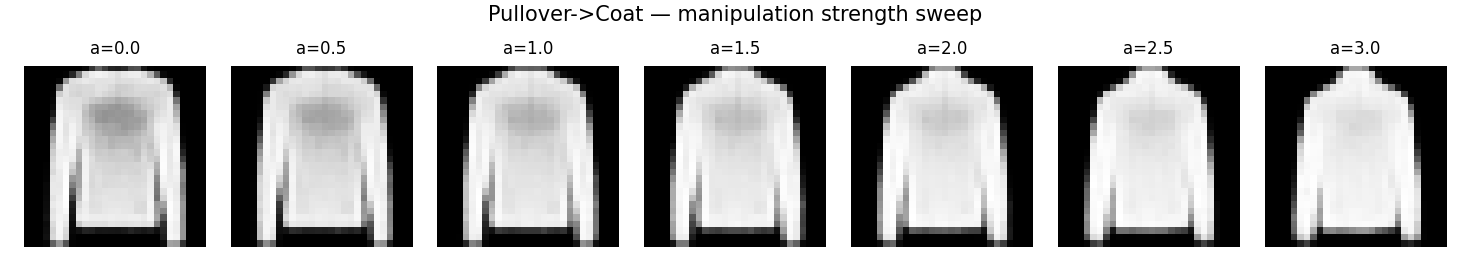

attribute_manipulation_Sneaker-Ankle_boot.png


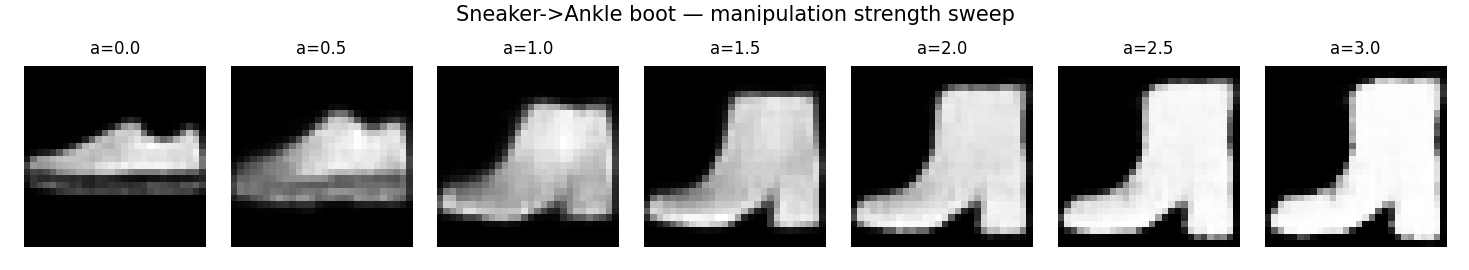

attribute_manipulation_T-shirt-top-Shirt.png


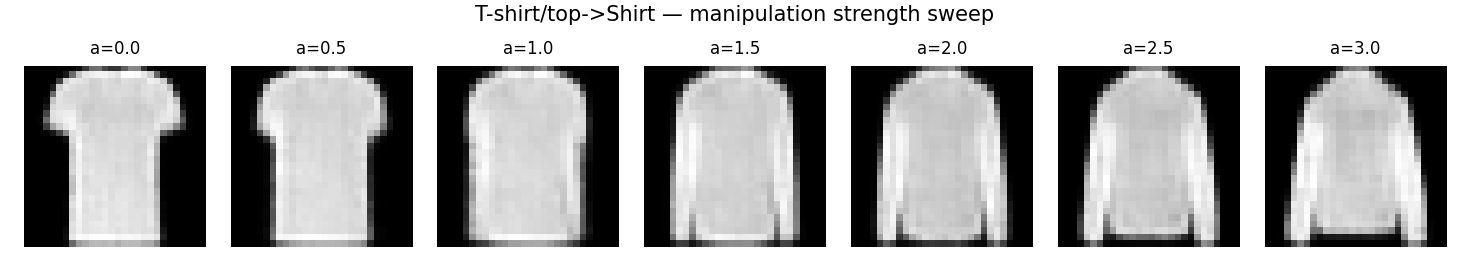

latent_space_pca.png


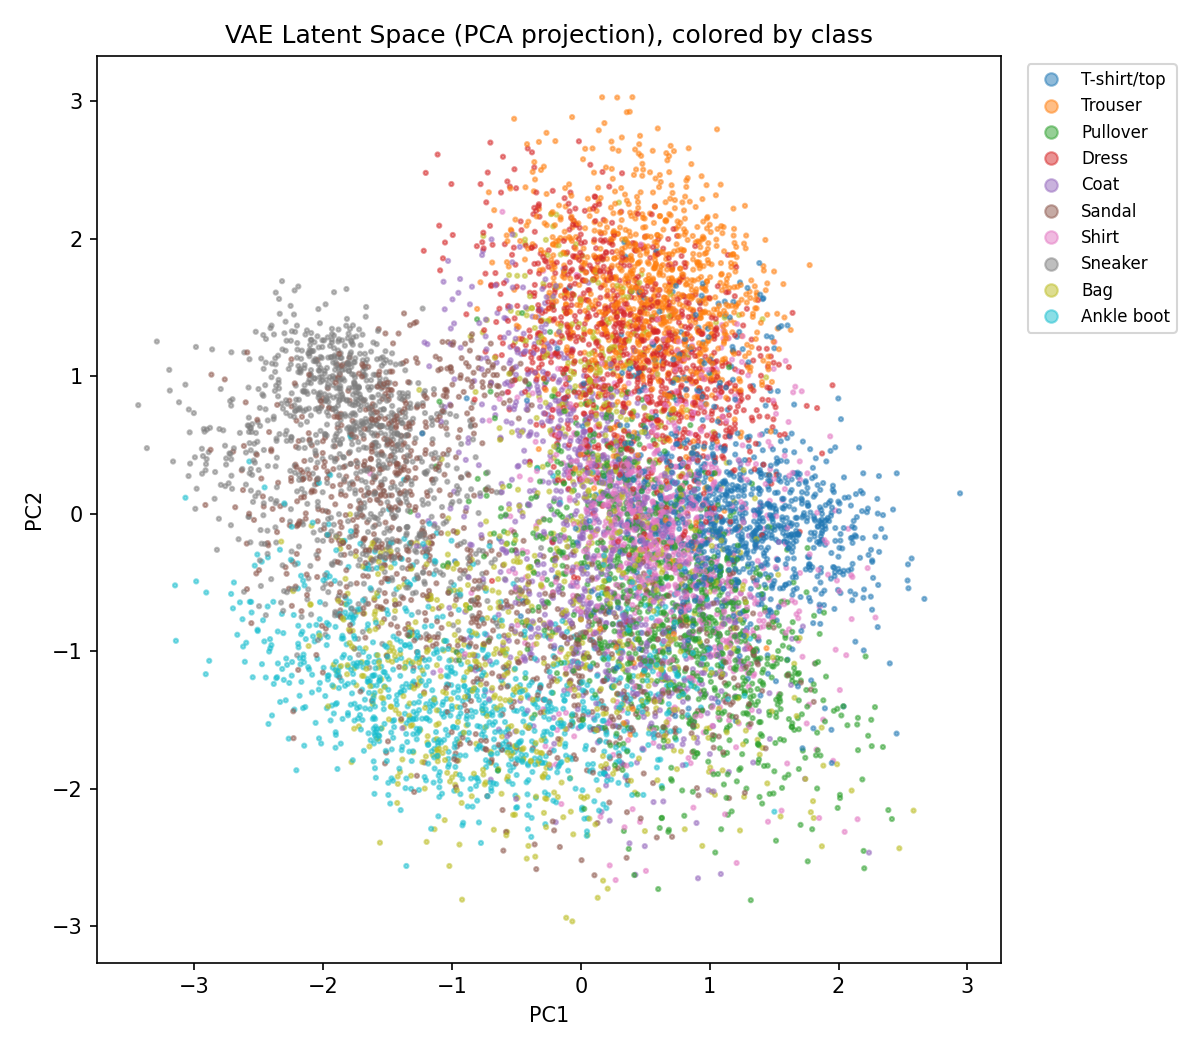

manipulation_success_curve.png


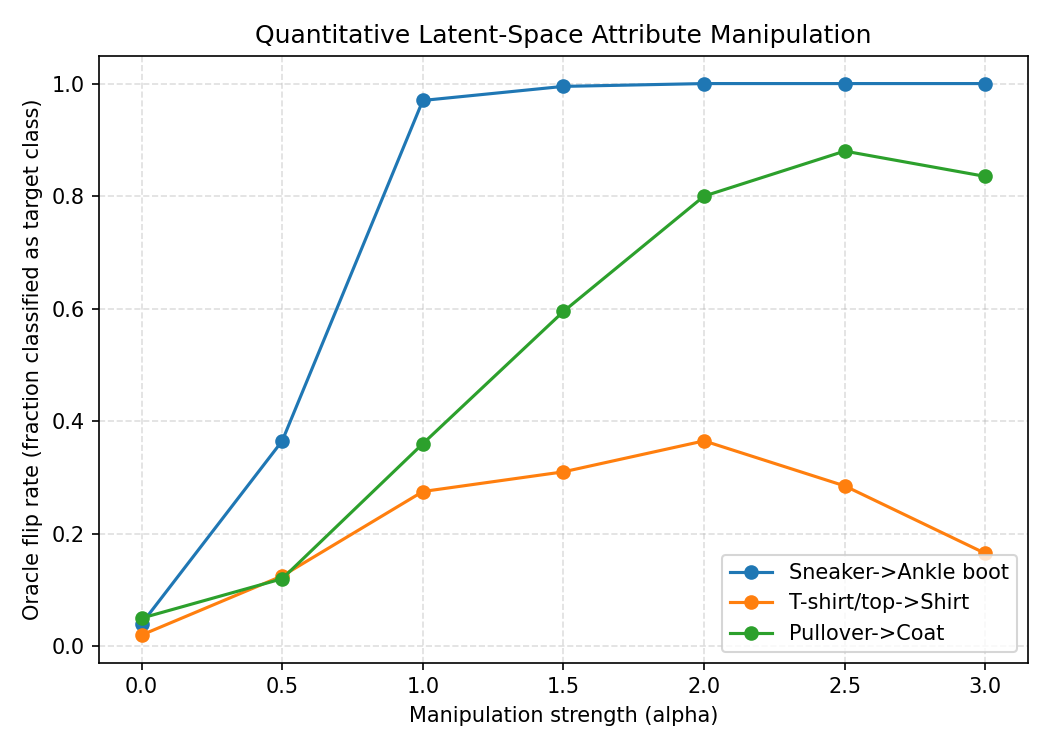

vae_interpolation.png


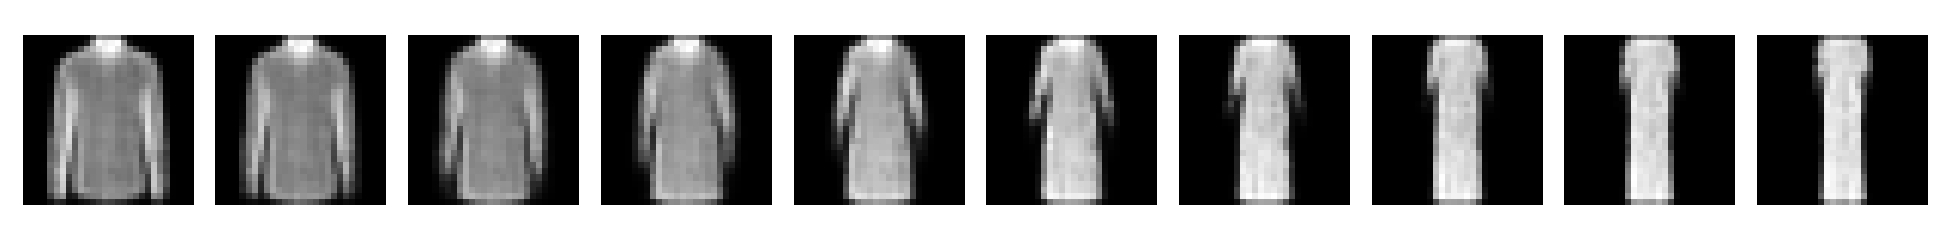

vae_random_samples.png


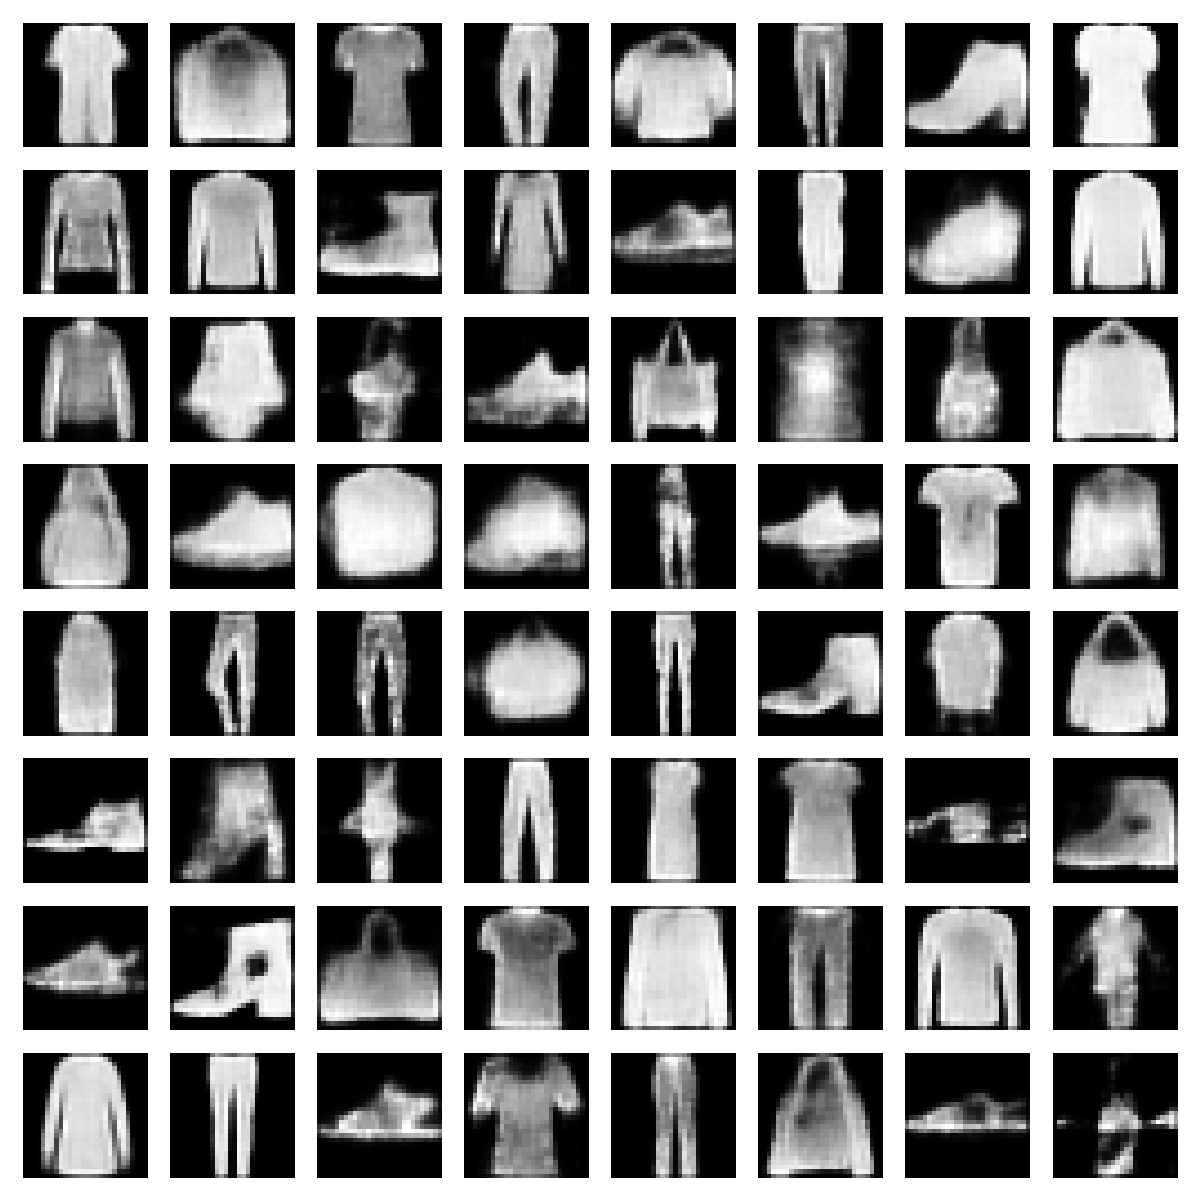

vae_reconstructions.png


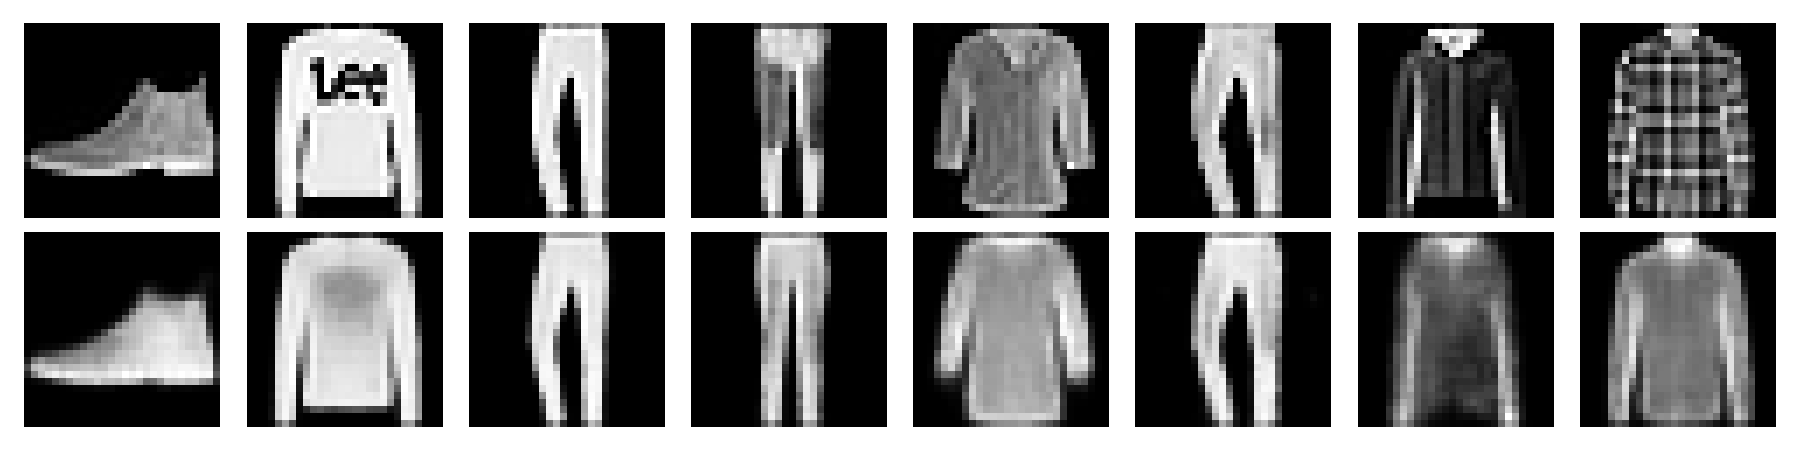

In [8]:
from IPython.display import Image, display
import os

image_files = sorted([f for f in os.listdir("results") if f.endswith(".png")])
for fname in image_files:
    print(fname)
    display(Image(filename=os.path.join("results", fname)))